
Logistic Regression Performance:
Accuracy: 0.9737, Precision: 0.9756, Recall: 0.9524, F1-score: 0.9639
Confusion Matrix:
 [[71  1]
 [ 2 40]]

K-Nearest Neighbors Performance:
Accuracy: 0.9561, Precision: 0.9744, Recall: 0.9048, F1-score: 0.9383
Confusion Matrix:
 [[71  1]
 [ 4 38]]

SVM (Linear) Performance:
Accuracy: 0.9737, Precision: 0.9756, Recall: 0.9524, F1-score: 0.9639
Confusion Matrix:
 [[71  1]
 [ 2 40]]

SVM (RBF) Performance:
Accuracy: 0.9825, Precision: 0.9762, Recall: 0.9762, F1-score: 0.9762
Confusion Matrix:
 [[71  1]
 [ 1 41]]

Decision Tree Performance:
Accuracy: 0.9211, Precision: 0.9231, Recall: 0.8571, F1-score: 0.8889
Confusion Matrix:
 [[69  3]
 [ 6 36]]


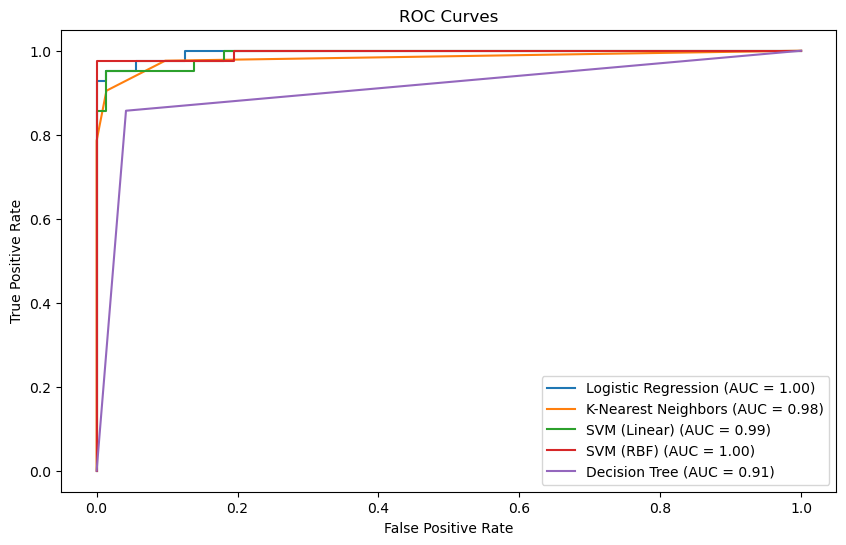

Best parameters for Logistic Regression: {'C': 0.1}
Best parameters for K-Nearest Neighbors: {'n_neighbors': 7}
Best parameters for SVM (RBF): {'C': 10, 'gamma': 'scale'}
Best parameters for Decision Tree: {'max_depth': 10}

Final Model Performance:
                     Accuracy  Precision    Recall  F1-score
Logistic Regression  0.973684   0.975610  0.952381  0.963855
K-Nearest Neighbors  0.956140   0.974359  0.904762  0.938272
SVM (Linear)         0.973684   0.975610  0.952381  0.963855
SVM (RBF)            0.982456   0.976190  0.976190  0.976190
Decision Tree        0.921053   0.923077  0.857143  0.888889


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

# Load dataset
file_path = r"C:\Users\PC\Downloads\data.csv"
df = pd.read_csv(file_path)

# Drop empty or unnecessary columns
df.drop(columns=['Unnamed: 32'], inplace=True, errors='ignore')

# Encode categorical variables
if 'diagnosis' in df.columns:
    df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Handle missing values
imputer = SimpleImputer(strategy='mean')
df.iloc[:, 1:] = imputer.fit_transform(df.iloc[:, 1:])  # Exclude ID column if present

# Define features and target
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "SVM (Linear)": SVC(kernel='linear', probability=True),
    "SVM (RBF)": SVC(kernel='rbf', probability=True),
    "Decision Tree": DecisionTreeClassifier()
}

# Train and evaluate models
results = {}
plt.figure(figsize=(10, 6))
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Compute metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)

    results[name] = {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1-score": f1}
    
    print(f"\n{name} Performance:")
    print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")
    print("Confusion Matrix:\n", conf_matrix)
    
    # Plot ROC curve if applicable
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# Plot ROC Curves
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

# Hyperparameter tuning with GridSearchCV
param_grid = {
    "Logistic Regression": {'C': [0.01, 0.1, 1, 10]},
    "K-Nearest Neighbors": {'n_neighbors': [3, 5, 7, 9]},
    "SVM (RBF)": {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']},
    "Decision Tree": {'max_depth': [3, 5, 10, None]}
}

best_models = {}
for name, params in param_grid.items():
    model = models[name]
    grid_search = GridSearchCV(model, params, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    best_models[name] = grid_search.best_estimator_
    print(f"Best parameters for {name}: {grid_search.best_params_}")
